In [1]:
pip install -r requirement.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os

In [3]:
import copy

In [4]:
import numpy as np

In [5]:
import pandas as pd

In [6]:
import torch

In [7]:
import torch.nn as nn

In [8]:
import torch.optim as optim

In [9]:
import matplotlib.pyplot as plt 

In [10]:
from torch.utils.data import TensorDataset, DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [11]:
os.makedirs("saved_models", exist_ok=True)

In [12]:
CSV_PATH = "diabetes_binary_health_indicators_BRFSS2015.csv"

In [13]:
TARGET_COLUMN = "Diabetes_binary"

In [14]:
NUM_CLIENTS = 5

In [15]:
ROUNDS=10

In [16]:
LOCAL_EPOCHS=1

In [17]:
BATCH_SIZE=256

In [18]:
LEARNING_RATE=0.001

In [19]:
USE_SAMPLE = False
SAMPLE_SIZE = 80000

In [20]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [21]:
class DiabetesMLP(nn.Module):
    def __init__(self, input_size):
        super(DiabetesMLP, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 2)
        )

    def forward(self, x):
        return self.network(x)

In [22]:
def load_dataset():
    df = pd.read_csv(CSV_PATH)

    if USE_SAMPLE:
        df = df.sample(n=SAMPLE_SIZE, random_state=42)

    print("Dataset loaded successfully")
    print("Dataset shape:", df.shape)
    print("Target column distribution:")
    print(df[TARGET_COLUMN].value_counts())

    X = df.drop(columns=[TARGET_COLUMN])
    y = df[TARGET_COLUMN]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)

    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

    return train_dataset, test_dataset, y_train_tensor, X_train.shape[1]

In [23]:
def create_iid_clients(train_dataset):
    total_size = len(train_dataset)
    indices = np.arange(total_size)

    np.random.shuffle(indices)

    client_indices = np.array_split(indices, NUM_CLIENTS)

    return [list(client) for client in client_indices]

In [24]:
def create_non_iid_clients(y_train_tensor):
    y_numpy = y_train_tensor.numpy()

    class_0_indices = np.where(y_numpy == 0)[0]
    class_1_indices = np.where(y_numpy == 1)[0]

    np.random.shuffle(class_0_indices)
    np.random.shuffle(class_1_indices)

    class_0_split = np.array_split(class_0_indices, NUM_CLIENTS)
    class_1_split = np.array_split(class_1_indices, NUM_CLIENTS)

    client_indices = []

    for client_id in range(NUM_CLIENTS):
        if client_id == 0:
            client_data = np.concatenate([
                class_0_split[client_id],
                class_1_split[client_id][:len(class_1_split[client_id]) // 5]
            ])

        elif client_id == 1:
            client_data = np.concatenate([
                class_0_split[client_id],
                class_1_split[client_id][:len(class_1_split[client_id]) // 3]
            ])

        elif client_id == 2:
            client_data = np.concatenate([
                class_0_split[client_id],
                class_1_split[client_id]
            ])

        elif client_id == 3:
            client_data = np.concatenate([
                class_0_split[client_id][:len(class_0_split[client_id]) // 2],
                class_1_split[client_id]
            ])

        else:
            client_data = np.concatenate([
                class_0_split[client_id][:len(class_0_split[client_id]) // 3],
                class_1_split[client_id]
            ])

        np.random.shuffle(client_data)
        client_indices.append(list(client_data))

    return client_indices

In [25]:
def train_one_client(model, train_loader):
    model.train()

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    total_loss = 0

    for epoch in range(LOCAL_EPOCHS):
        for features, labels in train_loader:
            features = features.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad()

            outputs = model(features)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

    return model.state_dict(), total_loss


In [26]:
def federated_average(client_weights):
    global_weights = copy.deepcopy(client_weights[0])

    for key in global_weights.keys():
        for i in range(1, len(client_weights)):
            global_weights[key] += client_weights[i][key]

        global_weights[key] = global_weights[key] / len(client_weights)

    return global_weights

In [27]:

def add_differential_privacy_noise(weights, noise_scale=0.001):
    noisy_weights = copy.deepcopy(weights)

    for key in noisy_weights.keys():
        noise = torch.randn_like(noisy_weights[key]) * noise_scale
        noisy_weights[key] += noise

    return noisy_weights

In [28]:
def evaluate_model(model, test_dataset):
    model.eval()

    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for features, labels in test_loader:
            features = features.to(DEVICE)

            outputs = model(features)

            predictions = torch.argmax(outputs, dim=1)

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.numpy())

    accuracy = accuracy_score(all_labels, all_predictions)

    return accuracy * 100


In [29]:
def calculate_model_size(model):
    total_params = 0

    for parameter in model.parameters():
        total_params += parameter.numel()

    model_size_mb = total_params * 4 / (1024 * 1024)

    return model_size_mb

In [30]:
def run_centralized_training(train_dataset, test_dataset, input_size):
    model = DiabetesMLP(input_size).to(DEVICE)

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    accuracy_history = []

    for epoch in range(ROUNDS):
        model.train()

        for features, labels in train_loader:
            features = features.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad()

            outputs = model(features)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

        accuracy = evaluate_model(model, test_dataset)
        accuracy_history.append(accuracy)

        print(f"Centralized Epoch {epoch + 1}: Accuracy = {accuracy:.2f}%")
    torch.save(model.state_dict(), "saved_models/centralized_model.pth")
    print("Centralized model saved successfully.")
    return accuracy_history


In [31]:
def run_federated_learning(
    train_dataset,
    test_dataset,
    input_size,
    client_indices,
    use_dp=False,
    experiment_name="FL"
):
    global_model = DiabetesMLP(input_size).to(DEVICE)

    accuracy_history = []
    communication_history = []

    model_size_mb = calculate_model_size(global_model)
    communication_per_round = model_size_mb * NUM_CLIENTS * 2

    print("\nExperiment:", experiment_name)
    print("Model size:", round(model_size_mb, 4), "MB")
    print("Communication per round:", round(communication_per_round, 4), "MB")

    for round_number in range(ROUNDS):
        client_weights = []

        for client_id in range(NUM_CLIENTS):
            local_model = copy.deepcopy(global_model)

            client_dataset = Subset(train_dataset, client_indices[client_id])

            client_loader = DataLoader(
                client_dataset,
                batch_size=BATCH_SIZE,
                shuffle=True
            )

            weights, loss = train_one_client(local_model, client_loader)

            if use_dp:
                weights = add_differential_privacy_noise(weights)

            client_weights.append(weights)

        global_weights = federated_average(client_weights)

        global_model.load_state_dict(global_weights)

        accuracy = evaluate_model(global_model, test_dataset)

        total_communication = communication_per_round * (round_number + 1)

        accuracy_history.append(accuracy)
        communication_history.append(total_communication)

        print(
            f"Round {round_number + 1}: "
            f"Accuracy = {accuracy:.2f}%, "
            f"Communication = {total_communication:.4f} MB"
        )
    model_file_name = experiment_name.replace(" ", "_").replace("+", "plus")

    torch.save(
        global_model.state_dict(),
        f"saved_models/{model_file_name}.pth"
    )

    print(f"{experiment_name} model saved successfully.")
    return accuracy_history, communication_history

In [32]:
def plot_results(
    centralized_accuracy,
    fl_iid_accuracy,
    fl_non_iid_accuracy,
    fl_non_iid_dp_accuracy,
    communication_history
):
    os.makedirs("plots", exist_ok=True)

    rounds = range(1, ROUNDS + 1)

    plt.figure()
    plt.plot(rounds, centralized_accuracy, marker="o", label="Centralized")
    plt.plot(rounds, fl_iid_accuracy, marker="o", label="FL-IID")
    plt.plot(rounds, fl_non_iid_accuracy, marker="o", label="FL-Non-IID")
    plt.plot(rounds, fl_non_iid_dp_accuracy, marker="o", label="FL-Non-IID + DP")
    plt.xlabel("Rounds / Epochs")
    plt.ylabel("Accuracy (%)")
    plt.title("Accuracy Comparison")
    plt.legend()
    plt.grid(True)
    plt.savefig("plots/accuracy_comparison.png")
    plt.show()

    plt.figure()
    plt.plot(rounds, fl_non_iid_accuracy, marker="o", label="FL-Non-IID")
    plt.plot(rounds, fl_non_iid_dp_accuracy, marker="o", label="FL-Non-IID + DP")
    plt.xlabel("Federated Rounds")
    plt.ylabel("Accuracy (%)")
    plt.title("Training Convergence")
    plt.legend()
    plt.grid(True)
    plt.savefig("plots/training_convergence.png")
    plt.show()

    plt.figure()
    plt.plot(rounds, communication_history, marker="o")
    plt.xlabel("Federated Rounds")
    plt.ylabel("Communication Overhead MB")
    plt.title("Communication Overhead")
    plt.grid(True)
    plt.savefig("plots/communication_overhead.png")
    plt.show()

In [33]:
def save_results(
    centralized_accuracy,
    fl_iid_accuracy,
    fl_non_iid_accuracy,
    fl_non_iid_dp_accuracy,
    communication_history
):
    os.makedirs("results", exist_ok=True)

    results_df = pd.DataFrame({
        "Round": list(range(1, ROUNDS + 1)),
        "Centralized_Accuracy": centralized_accuracy,
        "FL_IID_Accuracy": fl_iid_accuracy,
        "FL_Non_IID_Accuracy": fl_non_iid_accuracy,
        "FL_Non_IID_DP_Accuracy": fl_non_iid_dp_accuracy,
        "Communication_MB": communication_history
    })

    results_df.to_csv("results/accuracy_comparison.csv", index=False)

    print("\nResults saved in results/accuracy_comparison.csv")


In [34]:
def main():
    train_dataset, test_dataset, y_train_tensor, input_size = load_dataset()

    iid_client_indices = create_iid_clients(train_dataset)
    non_iid_client_indices = create_non_iid_clients(y_train_tensor)

    print("\nRunning centralized training...")
    centralized_accuracy = run_centralized_training(
        train_dataset,
        test_dataset,
        input_size
    )

    print("\nRunning FL with IID data...")
    fl_iid_accuracy, _ = run_federated_learning(
        train_dataset,
        test_dataset,
        input_size,
        iid_client_indices,
        use_dp=False,
        experiment_name="FL-IID"
    )

    print("\nRunning FL with Non-IID data...")
    fl_non_iid_accuracy, communication_history = run_federated_learning(
        train_dataset,
        test_dataset,
        input_size,
        non_iid_client_indices,
        use_dp=False,
        experiment_name="FL-Non-IID"
    )

    print("\nRunning FL with Non-IID data and Differential Privacy...")
    fl_non_iid_dp_accuracy, _ = run_federated_learning(
        train_dataset,
        test_dataset,
        input_size,
        non_iid_client_indices,
        use_dp=True,
        experiment_name="FL-Non-IID + DP"
    )

    plot_results(
        centralized_accuracy,
        fl_iid_accuracy,
        fl_non_iid_accuracy,
        fl_non_iid_dp_accuracy,
        communication_history
    )

    save_results(
        centralized_accuracy,
        fl_iid_accuracy,
        fl_non_iid_accuracy,
        fl_non_iid_dp_accuracy,
        communication_history
    )


Dataset loaded successfully
Dataset shape: (253680, 22)
Target column distribution:
Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64

Running centralized training...
Centralized Epoch 1: Accuracy = 86.48%
Centralized Epoch 2: Accuracy = 86.47%
Centralized Epoch 3: Accuracy = 86.44%
Centralized Epoch 4: Accuracy = 86.49%
Centralized Epoch 5: Accuracy = 86.50%
Centralized Epoch 6: Accuracy = 86.51%
Centralized Epoch 7: Accuracy = 86.55%
Centralized Epoch 8: Accuracy = 86.41%
Centralized Epoch 9: Accuracy = 86.46%
Centralized Epoch 10: Accuracy = 86.51%
Centralized model saved successfully.

Running FL with IID data...

Experiment: FL-IID
Model size: 0.0136 MB
Communication per round: 0.1356 MB
Round 1: Accuracy = 86.17%, Communication = 0.1356 MB
Round 2: Accuracy = 86.41%, Communication = 0.2711 MB
Round 3: Accuracy = 86.48%, Communication = 0.4067 MB
Round 4: Accuracy = 86.51%, Communication = 0.5423 MB
Round 5: Accuracy = 86.53%, Communication = 0.6779 MB
Round 6:

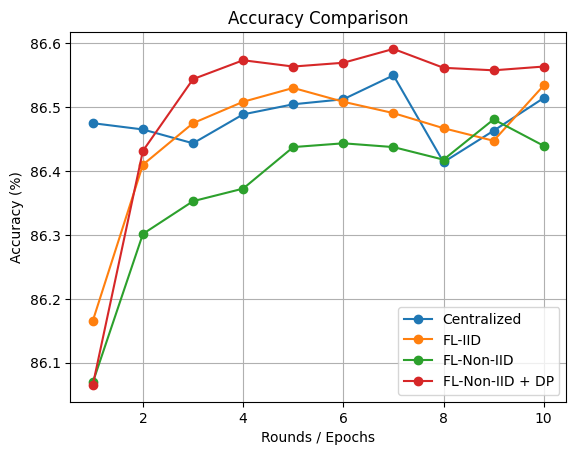

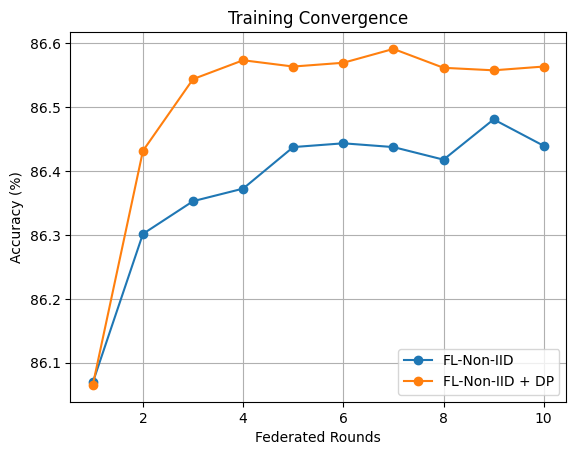

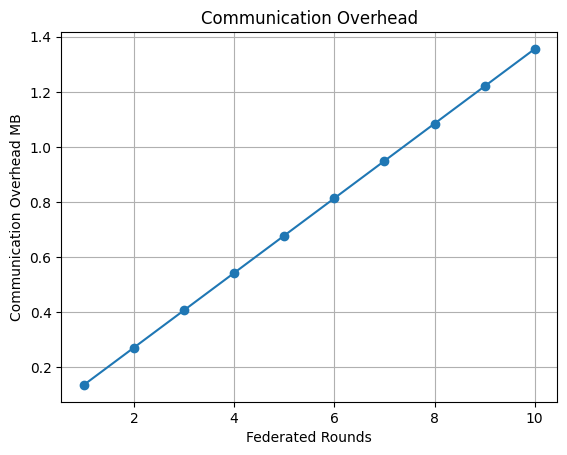


Results saved in results/accuracy_comparison.csv


In [35]:
if __name__ == "__main__":
    main()

In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import pandas as pd
import torch
from torch.utils.data import DataLoader
import os


def evaluate_saved_model(model_path, test_dataset, input_size, experiment_name):
    model = DiabetesMLP(input_size).to(DEVICE)

    model.load_state_dict(torch.load(model_path, map_location=DEVICE))

    model.eval()

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for features, labels in test_loader:
            features = features.to(DEVICE)

            outputs = model(features)

            predictions = torch.argmax(outputs, dim=1)

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.numpy())

    accuracy = accuracy_score(all_labels, all_predictions) * 100

    precision = precision_score(
        all_labels,
        all_predictions,
        pos_label=1,
        zero_division=0
    ) * 100

    recall = recall_score(
        all_labels,
        all_predictions,
        pos_label=1,
        zero_division=0
    ) * 100

    f1 = f1_score(
        all_labels,
        all_predictions,
        pos_label=1,
        zero_division=0
    ) * 100

    cm = confusion_matrix(all_labels, all_predictions)

    print("\n===================================")
    print("Experiment:", experiment_name)
    print("===================================")
    print(f"Accuracy  : {accuracy:.2f}%")
    print(f"Precision : {precision:.2f}%")
    print(f"Recall    : {recall:.2f}%")
    print(f"F1-score  : {f1:.2f}%")

    print("\nConfusion Matrix:")
    print(cm)

    print("\nClassification Report:")
    print(
        classification_report(
            all_labels,
            all_predictions,
            target_names=["No Diabetes", "Diabetes"],
            zero_division=0
        )
    )

    return {
        "Experiment": experiment_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1_score": f1,
        "TN": cm[0][0],
        "FP": cm[0][1],
        "FN": cm[1][0],
        "TP": cm[1][1]
    }


train_dataset, test_dataset, y_train_tensor, input_size = load_dataset()

metrics_results = []

metrics_results.append(
    evaluate_saved_model(
        "saved_models/centralized_model.pth",
        test_dataset,
        input_size,
        "Centralized Training"
    )
)

metrics_results.append(
    evaluate_saved_model(
        "saved_models/FL-IID.pth",
        test_dataset,
        input_size,
        "FL-IID"
    )
)

metrics_results.append(
    evaluate_saved_model(
        "saved_models/FL-Non-IID.pth",
        test_dataset,
        input_size,
        "FL-Non-IID"
    )
)

metrics_results.append(
    evaluate_saved_model(
        "saved_models/FL-Non-IID_plus_DP.pth",
        test_dataset,
        input_size,
        "FL-Non-IID + DP"
    )
)

metrics_df = pd.DataFrame(metrics_results)

os.makedirs("results", exist_ok=True)

metrics_df.to_csv(
    "results/final_saved_model_metrics.csv",
    index=False
)

print("\nFinal saved model metrics:")
print(metrics_df)

Dataset loaded successfully
Dataset shape: (253680, 22)
Target column distribution:
Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64

Experiment: Centralized Training
Accuracy  : 86.51%
Precision : 56.14%
Recall    : 14.68%
F1-score  : 23.28%

Confusion Matrix:
[[42856   811]
 [ 6031  1038]]

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.88      0.98      0.93     43667
    Diabetes       0.56      0.15      0.23      7069

    accuracy                           0.87     50736
   macro avg       0.72      0.56      0.58     50736
weighted avg       0.83      0.87      0.83     50736


Experiment: FL-IID
Accuracy  : 86.53%
Precision : 56.40%
Recall    : 14.77%
F1-score  : 23.41%

Confusion Matrix:
[[42860   807]
 [ 6025  1044]]

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.88      0.98      0.93     43667
    Diabetes       0.56      0.15      0.23      7069

 